# User Progress Model

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import joblib, pickle

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (classification_report, mean_absolute_error, 
                            mean_squared_error, r2_score, accuracy_score)

import xgboost as xgb
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

## Exploratory Data Analysis (EDA)

C:\Users\viole\AppData\Local\Temp\ipykernel_29536\488073254.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_users, x='Gender', palette='pastel')
C:\Users\viole\AppData\Local\Temp\ipykernel_29536\488073254.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_users, x='BMI_Category_x', palette='Set2')
C:\Users\viole\AppData\Local\Temp\ipykernel_29536\488073254.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_users, x='Goal', palette='Set3')


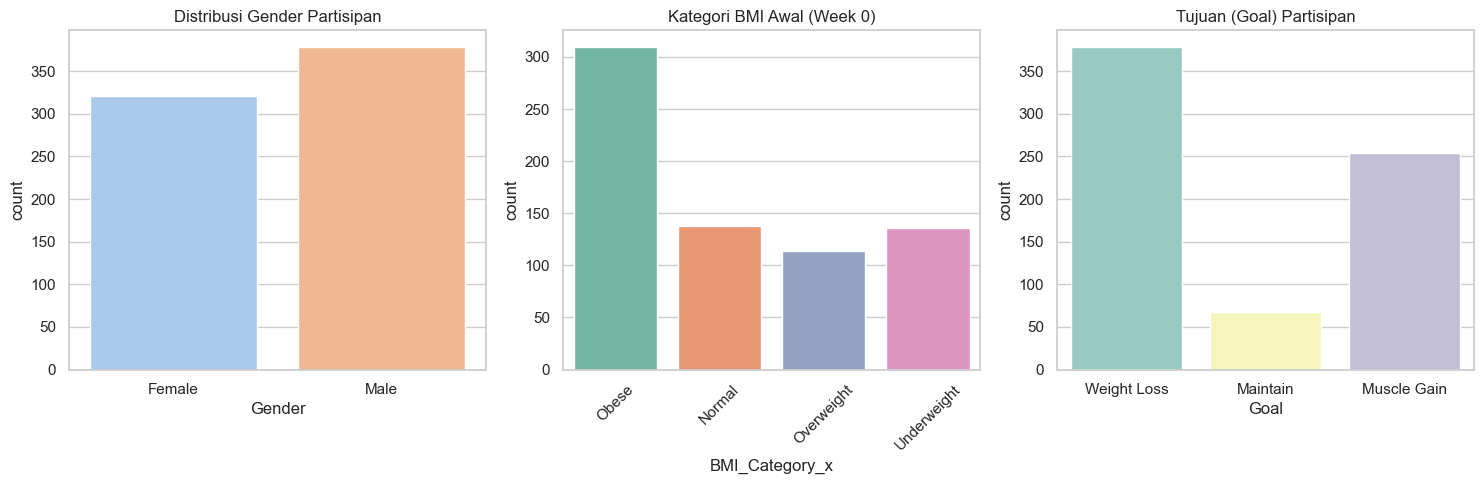

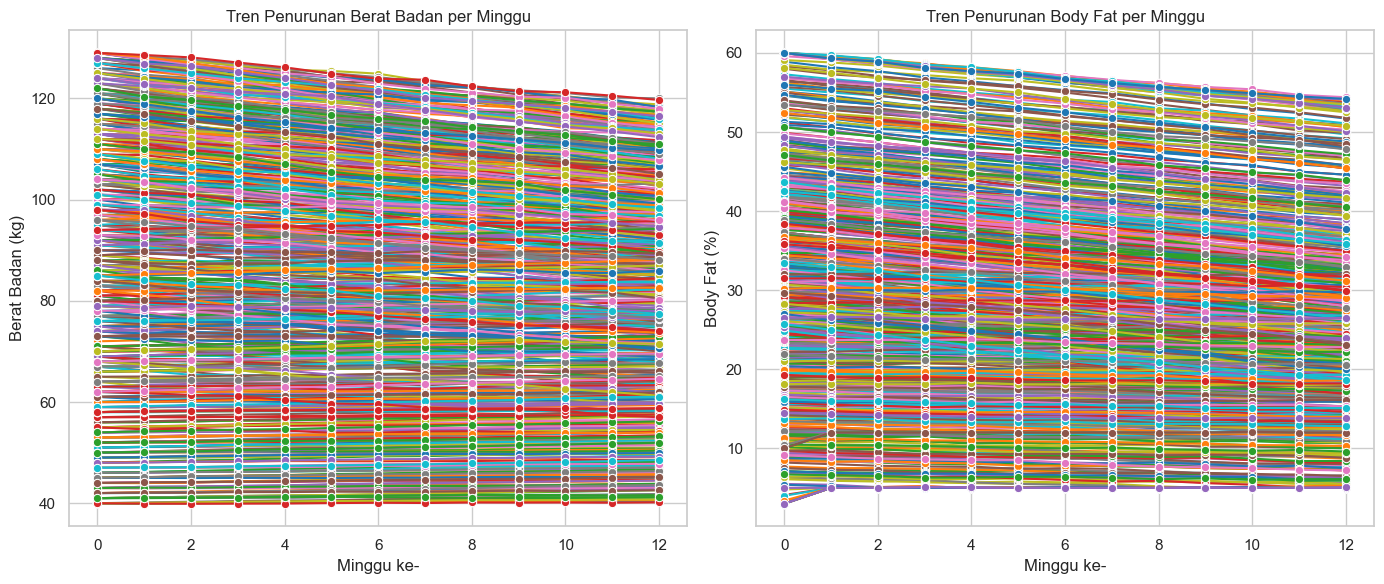

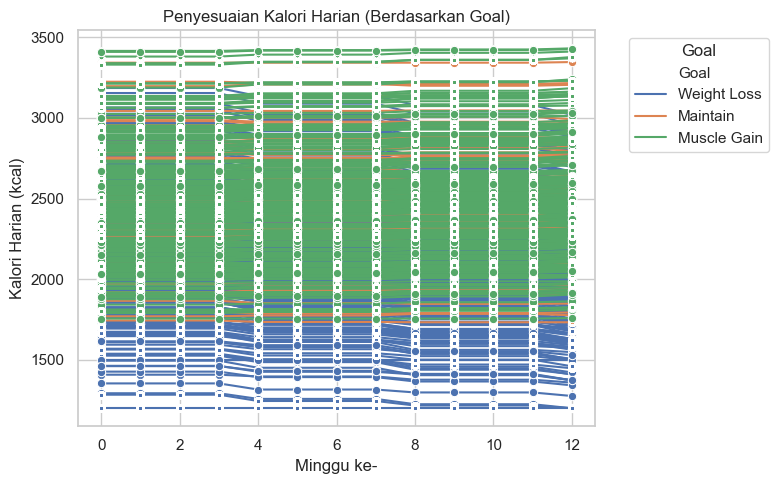

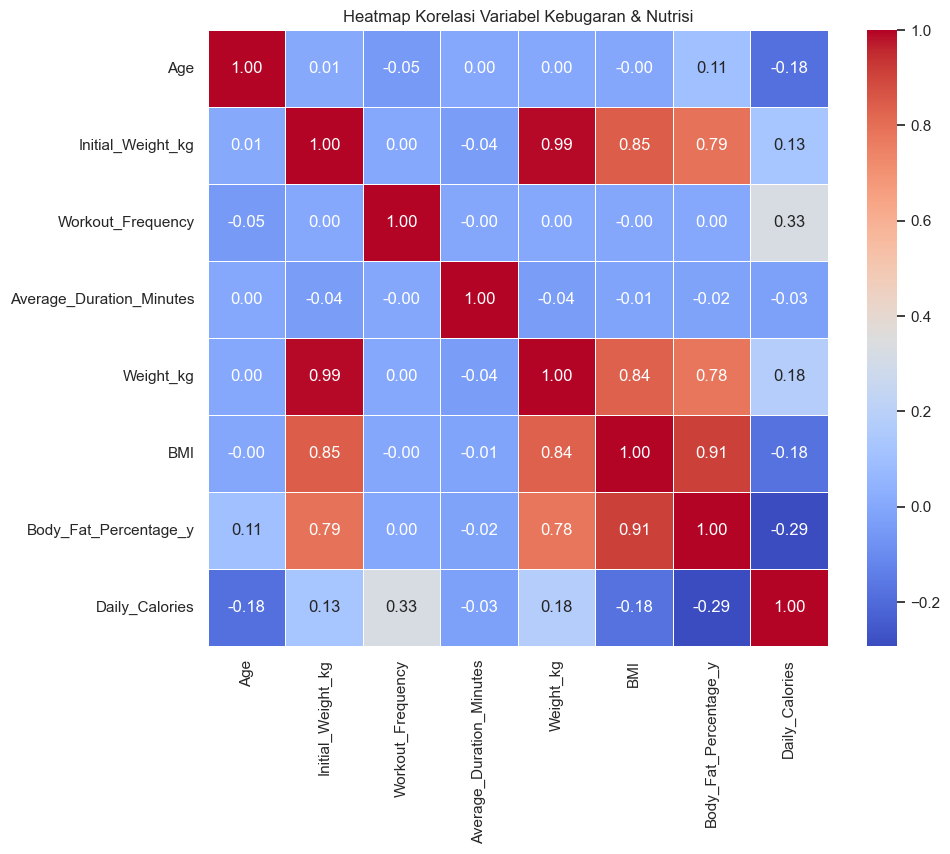

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATASET
# Ganti 'data_fitness.csv' dengan nama file CSV aslimu
df = pd.read_csv('../../data/dataset_userprogress.csv')

# Setup tema visualisasi
sns.set_theme(style="whitegrid")

# 2. PROFIL PENGGUNA (Mengambil data unik per User, misal di Week 0)
df_users = df[df['Week'] == 0]

plt.figure(figsize=(15, 5))

# Distribusi Gender
plt.subplot(1, 3, 1)
sns.countplot(data=df_users, x='Gender', palette='pastel')
plt.title('Distribusi Gender Partisipan')

# Distribusi Kategori BMI Awal
plt.subplot(1, 3, 2)
sns.countplot(data=df_users, x='BMI_Category_x', palette='Set2')
plt.title('Kategori BMI Awal (Week 0)')
plt.xticks(rotation=45)

# Distribusi Goal
plt.subplot(1, 3, 3)
sns.countplot(data=df_users, x='Goal', palette='Set3')
plt.title('Tujuan (Goal) Partisipan')

plt.tight_layout()
plt.show()

# 3. TREN PROGRESS PER MINGGU (Longitudinal)
plt.figure(figsize=(14, 6))

# Perubahan Berat Badan
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='Week', y='Weight_kg', hue='User_ID', marker='o', palette='tab10', legend=False)
plt.title('Tren Penurunan Berat Badan per Minggu')
plt.xlabel('Minggu ke-')
plt.ylabel('Berat Badan (kg)')

# Perubahan Persentase Lemak Tubuh
plt.subplot(1, 2, 2)
sns.lineplot(data=df, x='Week', y='Body_Fat_Percentage_y', hue='User_ID', marker='o', palette='tab10', legend=False)
plt.title('Tren Penurunan Body Fat per Minggu')
plt.xlabel('Minggu ke-')
plt.ylabel('Body Fat (%)')

plt.tight_layout()
plt.show()

# 4. PENYESUAIAN NUTRISI
plt.figure(figsize=(8, 5))

# Simpan plot ke dalam variabel 'ax'
ax = sns.lineplot(data=df, x='Week', y='Daily_Calories', hue='Goal', style='User_ID', markers=True, dashes=False)

plt.title('Penyesuaian Kalori Harian (Berdasarkan Goal)')
plt.xlabel('Minggu ke-')
plt.ylabel('Kalori Harian (kcal)')

# Trik memotong legend:
# Ambil semua komponen legend yang digenerate otomatis
handles, labels = ax.get_legend_handles_labels()

# Cari posisi label 'User_ID' dan potong list legend-nya sampai situ aja
if 'User_ID' in labels:
    idx = labels.index('User_ID')
    handles = handles[:idx]
    labels = labels[:idx]

# Buat legend baru dengan data yang sudah dipotong
plt.legend(handles=handles, labels=labels, title='Goal', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. KORELASI ANTAR VARIABEL NUMERIK
cols_to_corr = ['Age', 'Initial_Weight_kg', 'Workout_Frequency', 'Average_Duration_Minutes', 
                'Weight_kg', 'BMI', 'Body_Fat_Percentage_y', 'Daily_Calories']

plt.figure(figsize=(10, 8))
corr_matrix = df[cols_to_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Kebugaran & Nutrisi')
plt.show()

## Global Configuration

In [32]:
# Define a specific number (Seed) to ensure the code behaves exactly the same way
# every time we run it. This prevents random changes in model scores.
SEED = 26

# Lock the random number generator of NumPy using our Seed.
np.random.seed(SEED)

# Configure Pandas to display ALL columns when printing a dataframe.
# By default, Pandas hides middle columns with "..." if there are too many.
# We disable this limit so we can inspect all our features during debugging.
pd.set_option('display.max_columns', None)

## Preprocessing Data

In [33]:
# Read the CSV file containing user progress history into a Pandas DataFrame.
# '../../datas/' indicates the file is located two folders up in a 'datas' directory.
# Ensure this path matches your actual folder structure.
df_progress = pd.read_csv('../../data/dataset_userprogress.csv')

# [Recommended] Quick Verification
# Print the first 5 rows and the shape (rows, columns) to confirm data loaded successfully.
# This helps catch errors like "FileNotFound" or empty files immediately.
print(f"Data Loaded Successfully. Shape: {df_progress.shape}")

Data Loaded Successfully. Shape: (9100, 33)


In [34]:
# The function tells us:
# 1. How many rows and columns we have.
# 2. The Name and Data Type (Dtype) of each column (int, float, object/text).
# 3. "Non-Null Count": If this number is lower than the total rows, we have missing data!
df_progress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9100 entries, 0 to 9099
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   9100 non-null   int64  
 1   Age                       9100 non-null   int64  
 2   Gender                    9100 non-null   object 
 3   Height_cm                 9100 non-null   int64  
 4   Initial_Weight_kg         9100 non-null   int64  
 5   Initial_BMI               9100 non-null   float64
 6   BMI_Category_x            9087 non-null   object 
 7   Body_Fat_Category         9100 non-null   float64
 8   Body_Fat_Percentage_x     9100 non-null   float64
 9   Goal                      9100 non-null   object 
 10  Workout_Frequency         9100 non-null   int64  
 11  Average_Duration_Minutes  9100 non-null   int64  
 12  level                     9100 non-null   object 
 13  Badminton                 9100 non-null   int64  
 14  Football

### Encoding Data

In [35]:
# Initialize a dictionary to store our Encoders
# The use of saving encoders:
# - To encode NEW data later (example, a new user registers as "Female", we need to know that = 0).
# - To decode predictions (example, Model predicts class "2", we need to know "2" = "Normal Weight").
le_dict = {}

# Define the map: Original Column Name -> New Numeric Column Name
cols_to_encode = {
    'Gender': 'Gender_Encoded',
    'Goal': 'Goal_Encoded',
    'level': 'level_Encoded',
    'Meal_Frequency': 'Meal_Frequency_Encoded',
    'BMI_Category_x': 'BMI_Category_x_Encoded',     # Input: The user's starting category
    'BMI_Category_y': 'BMI_Category_y_Encoded'      # Target: The category we want to predict
}

# Execution Loop
for col_name, col_encoded in cols_to_encode.items():
    # Create a specific translator for this column
    le = LabelEncoder()
    
    # fit_transform does two jobs:
    # - Fit: Learns the unique words (e.g., ["Beginner", "Intermediate", "Advanced"])
    # - Transform: Converts them to numbers (e.g., [0, 2, 1])
    df_progress[col_encoded] = le.fit_transform(df_progress[col_name])
    
    # Store the translator for future use
    le_dict[col_name] = le

### Splitting Dataset

We can't split data straight out or randomly, since we cant have same user but in train and test set because this will cause data leakage. So we need to divide and decide which set will the user be used for.

In [36]:
# Create a "User Profile" Table
# Problem: If we split random rows, User A's "Week 1" data might be in Train
# and User A's "Week 2" data in Test. The model would just memorize User A.
# Solution: We group by User_ID and take the first row to get their static profile.
user_metadata = df_progress.groupby('User_ID').first()

# Define Inputs for the Splitter
user_ids = user_metadata.index                    # List of unique User IDs (e.g., [1, 2, 3...])
stratify_labels = user_metadata['BMI_Category_y'] # The target we want to balance.

# The use of stratify:
# If we have 100 users and only 5 are "Obese", a random split might put all 5 in Train.
# Stratify forces the split to put ~3 in Train and ~2 in Test, so we can test properly.

# Perform the Split
train_users, test_users = train_test_split(
    user_ids,                # We split the IDs, not the full dataframe
    test_size=0.3,           # 30% of users go to the Test Set
    random_state=SEED,       # Ensures we get the exact same users every time
    stratify=stratify_labels # Ensures fair distribution of BMI categories
)

# After this, 'train_users' is a list of ID numbers. We will filter the main dataframe next.
print(f"Split Result: {len(train_users)} Train Users, {len(test_users)} Test Users")

Split Result: 490 Train Users, 210 Test Users


In [37]:
# Give me all rows where the User_ID is inside the train_users list and create a new independent table with .copy().
df_train = df_progress[df_progress['User_ID'].isin(train_users)].copy()

# Give me all rows where the User_ID is inside the test_users list and create a new independent table with .copy().
df_test = df_progress[df_progress['User_ID'].isin(test_users)].copy()

# Print the number of unique users in each set to confirm the split worked.
print(f"Final Split: {len(train_users)} Users in Train | {len(test_users)} Users in Test")

Final Split: 490 Users in Train | 210 Users in Test


## Modelling

In [38]:
# Input Features (X)
# These are the columns the model will "study" to make predictions.
features = [
    # User Profile
    'Age', 'Gender_Encoded', 'Height_cm', 
    'Initial_Weight_kg', 
    'Initial_BMI', 
    'BMI_Category_x_Encoded',
    
    # User Body Composition
    'Body_Fat_Category', 'Body_Fat_Percentage_x', 
    
    # User Lifestyle & Goals 
    'Goal_Encoded', 'Workout_Frequency', 'Average_Duration_Minutes', 'level_Encoded',
    
    # User Sports Interests 
    'Badminton', 'Football', 'Basketball', 'Volleyball', 'Swim',
    
    # Time Factor
    'Week',
]

# Create Feature Matrices
# Extract only the columns listed above from our Train/Test dataframes.
X_train = df_train[features]
X_test = df_test[features]

# Define Targets (y)
# These are the "Answers" we want the model to predict.

# Numeric Targets (Regression)
targets_num = [
    'Weight_kg', 'Body_Fat_Percentage_y', 'Daily_Calories', 
    'Daily_Water_ml', 'Target_Protein_g', 'Target_Carbs_g', 'Target_Fat_g',
    'Limit_Sugar_g', 'Target_Fiber_g'
]

### Model and Hyperparameter Tuning

In [39]:
# Dictionary to store trained models for later use
models = {}

# List to collect evaluation results for the final report
evaluation_report = []

# Hyperparameter Grid: The "Settings" we test to find the best model.
xgb_reg_params = {
    'n_estimators': [500, 1000],      # More trees = better learning
    'learning_rate': [0.01, 0.05],    # Slower = more precise
    'max_depth': [3, 5, 7],           # Depth of decision trees
    'subsample': [0.7, 0.9],          # Use 70-90% of rows (prevents overfitting)
    'colsample_bytree': [0.7, 0.9]    # Use 70-90% of columns (prevents overfitting)
}


# Regression loop to predict numerical columns
for t in targets_num:
    y_train = df_train[t]
    y_test = df_test[t]
    
    # Initialize Model
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
    
    # Hyperparameter Tuning
    # Tries 10 random combinations of settings to find the best one
    search = RandomizedSearchCV(xgb_model, xgb_reg_params, n_iter=10, cv=3, scoring='r2', verbose=0, random_state=42)
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    # Evaluate
    train_score = best_model.score(X_train, y_train) # R2 Score (0.0 to 1.0)
    test_score = best_model.score(X_test, y_test)
    test_mae = mean_absolute_error(y_test, best_model.predict(X_test))
    
    # Save & Log
    models[t] = {'model': best_model, 'type': 'numeric'}
    
    evaluation_report.append({
        'Target': t,
        'Type': 'Regression',
        'Train Score': f"{train_score*100:.1f}%",
        'Test Score': f"{test_score*100:.1f}%",
        'Gap': f"{(train_score-test_score)*100:.1f}%",
        'Error Metric': f"MAE: {test_mae:.2f}"
    })

# Creating evaluation for each target
results_df = pd.DataFrame(evaluation_report)
results_df = results_df[['Target', 'Type', 'Train Score', 'Test Score', 'Gap', 'Error Metric']]

print("\n=== Final Evaluation Report ===")
results_df


=== Final Evaluation Report ===


,Target,Type,Train Score,Test Score,Gap,Error Metric
0,Weight_kg,Regression,100.0%,99.9%,0.1%,MAE: 0.63
1,Body_Fat_Percentage_y,Regression,100.0%,99.9%,0.1%,MAE: 0.38
2,Daily_Calories,Regression,99.8%,98.3%,1.5%,MAE: 40.64
3,Daily_Water_ml,Regression,99.9%,99.8%,0.1%,MAE: 29.82
4,Target_Protein_g,Regression,99.8%,98.8%,1.0%,MAE: 3.24
5,Target_Carbs_g,Regression,99.9%,99.5%,0.5%,MAE: 4.23
6,Target_Fat_g,Regression,99.8%,98.8%,1.0%,MAE: 1.21
7,Limit_Sugar_g,Regression,99.7%,98.0%,1.7%,MAE: 1.08
8,Target_Fiber_g,Regression,99.6%,97.9%,1.7%,MAE: 0.62


### Model Dump

In [40]:
# We package everything into a single dictionary "box".
# This ensures that when we load the model later, we also have the
# exact encoders and feature list used to train it.
data_progress = {
    'models_dict': models,     # The Trained AI Models (The Brain)
    'encoders': le_dict,       # The Translators (Text -> Numbers)
    'features': features       # The Map (Order of inputs is CRITICAL!)
}

# Define the save path.
# 'wb' means "Write Binary" (required for saving models).
save_path = '../../models/model_progress.pickle'

with open(save_path, 'wb') as f:
    pickle.dump(data_progress, f)

print("\n 'model_progress.pickle' saved.")


 'model_progress.pickle' saved.
